#Setup

##Clone Tac2 (don't run if you've already cloned from monorepo)

In [ ]:
!git clone https://github.com/ZDisket/Comprehensive-Tacotron2.git -b ATSA
%cd Comprehensive-Tacotron2


## Install deps

In [ ]:
!apt-get -y install espeak-ng build-essential screen unzip libsndfile1
!pip install g2p-en phonemizer inflect librosa matplotlib pandas pypinyin python_speech_features pyworld PyYAML scikit-learn scikit-image scipy soundfile tensorboard tgt tqdm unidecode
!unzip ./hifigan/generator_universal.pth.tar.zip
!mv generator_universal.pth.tar hifigan

In [ ]:
SampleRate = 22050 
#==================================
root_path = "tac2out"
sarate = SampleRate # Your sample rate
#==================================
import subprocess
import json
import os
import librosa

from IPython.display import HTML, display
import time

def godir(condir):
  if os.getcwd() != condir:
    os.chdir(condir)

def shexec(ex):
  return subprocess.run(ex,shell=True)

import string
import random
def randomString(stringLength=10):
    """Generate a random string of fixed length """
    letters = string.ascii_lowercase
    return ''.join(random.choice(letters) for i in range(stringLength))



def safemkdir(dirn):
  if not os.path.isdir(dirn):
    os.mkdir(dirn)


import os

# Automatically fetches a Google Drive ID from a GD link
# Supports both https://drive.google.com/uc?id=XXX and https://drive.google.com/file/d/XXX/view?usp=sharing
def auto_fetch_gdid(gd_link):
  link_splits = gd_link.split("/")
  for li_chunk in link_splits:
    proc_chunk = li_chunk.replace("uc?id=","")
    if len(proc_chunk) == 33:
      return proc_chunk
  
  return ""

from g2p_en import G2p

g2p = G2p()
def g2pfil(intxt):
  sta = g2p(intxt)
  ret = " ".join(sta)
  return ret

def download_gdrive(file_id,out_filename,size_over_mb = 0):
  o_file_id = file_id
  if "https" in file_id:
    print("Link detected")
    file_id = auto_fetch_gdid(file_id)
  
  #sometimes it downloads a .html file of the virus warning, doesn't happen in the second time
  !curl -L -o '{out_filename}' 'https://drive.google.com/u/0/uc?id={file_id}&export=download&confirm=t'
  if ".py" in out_filename:
    !curl -L -o '{out_filename}' 'https://drive.google.com/u/0/uc?id={file_id}&export=download&confirm=t'

  #ensure that we didn't download an html
  if size_over_mb > 0 and os.path.getsize(out_filename) / 1e+6 < size_over_mb:
    !gdown --fuzzy {o_file_id} -O {out_filename}


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.


## Download model

In [ ]:
ModelGDriveURL = "https://drive.google.com/file/d/1oXtz3Yn5ri4UhwtvF21OnhPphD9SAFxr/view?usp=share_link" #@param {type:"string"}

tac2_model_name = "vits.pth"
import os, shutil
os.chdir("/content/Comprehensive-Tacotron2")
sarate = 44100

download_gdrive(ModelGDriveURL,tac2_model_name,100)

Link detected
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  343M  100  343M    0     0  36.9M      0  0:00:09  0:00:09 --:--:-- 54.2M


#Load model

In [ ]:
import os
import json
import argparse

import torch
import numpy as np
from torch.utils.data import DataLoader

from utils.model import get_model, get_vocoder
from utils.tools import get_configs_of, to_device, infer_one_sample #, read_lexicon
from dataset import TextDataset
from text import text_to_sequence, sequence_to_text

import hifigan
from model import Tacotron2
from text.cleaners import to_arpa 

def get_tac2(configs, device):
    (preprocess_config, model_config, train_config) = configs

    model = Tacotron2(preprocess_config, model_config, train_config).to(device)

    model.eval()
    model.requires_grad_ = False
    return model

dataset = "SingleSpk22"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def preprocess_english(text, preprocess_config):
    sequence = text_to_sequence(
        text, preprocess_config["preprocessing"]["text"]["text_cleaners"]
    )
    print("Raw Text Sequence: {}".format(text))
    print("Sequence: {}".format(" ".join([str(id) for id in sequence_to_text(sequence)])))
    print("Sequence Input: {}".format(" ".join([str(id) for id in sequence])))
    return np.array(sequence)

preprocess_config, model_config, train_config = get_configs_of(dataset)
configs = (preprocess_config, model_config, train_config)


model = get_tac2(configs, device)

ckpt = torch.load(tac2_model_name)
model.load_state_dict(ckpt["model"])

# Load vocoder
vocoder = get_vocoder(model_config, device)

Removing weight norm...


# Pre-Inference

## Aux functions

In [ ]:
import matplotlib
from scipy.io import wavfile
from matplotlib import pyplot as plt
from sklearn.manifold import TSNE

def visualize_attention(alignment_history):
  print(alignment_history.shape)
  import matplotlib.pyplot as plt
  %matplotlib inline

  fig = plt.figure(figsize=(8, 6))
  ax = fig.add_subplot(111)
  ax.set_title(f'Alignment steps')
  im = ax.imshow(
      alignment_history,
      aspect='auto',
      origin='lower',
      interpolation='none')
  fig.colorbar(im, ax=ax)
  xlabel = 'Decoder timestep'
  plt.xlabel(xlabel)
  plt.ylabel('Encoder timestep')
  plt.tight_layout()
  plt.show()
  plt.close()

def visualize_mel_spectrogram(mels):
  %matplotlib inline
  fig = plt.figure(figsize=(10, 8))
  ax1 = fig.add_subplot(311)
  ax1.set_title(f'Predicted Mel-after-Spectrogram')
  melsr = np.rot90(mels)
  im = ax1.imshow(melsr, aspect='auto', interpolation='none')
  fig.colorbar(mappable=im, shrink=0.65, orientation='horizontal', ax=ax1)
  plt.show()
  plt.close()

In [ ]:
from utils.tools import plot_mel 
from utils.model import vocoder_infer

%matplotlib inline
def do_inference(in_txt):
  txt_proc = preprocess_english(in_txt,preprocess_config)
  txt_proc = torch.from_numpy(txt_proc).unsqueeze(0).to(device) # [txt_len] => [1, txt_len]
  with torch.no_grad():
    output = model.inference(None,txt_proc)

    normalize = preprocess_config["preprocessing"]["mel"]["normalize"]
    n_frames_per_step = model_config["decoder"]["n_frames_per_step"]
    multi_speaker = model_config["multi_speaker"]

    predictions = output
    if normalize:
      mel_predictions = Audio.tools.mel_denormalize(output[1], *mel_stats)
    else:
      mel_predictions = output[1]

    

    print(mel_predictions.shape)
    mel_len = mel_predictions[0].shape[0]
    reduced_mel_len = mel_len // n_frames_per_step
    mel_prediction = mel_predictions[0].detach().transpose(0, 1)
    src_len = txt_proc.size(0)

    attention = predictions[3][0, :reduced_mel_len, :src_len].detach().transpose(0, 1) # [seq_len, mel_len]
    print(predictions[3].shape)

    visualize_mel_spectrogram(mel_prediction.transpose(0, 1).cpu().numpy())
    visualize_attention(predictions[3].squeeze().transpose(0, 1).cpu().numpy())



    lengths = mel_len * preprocess_config["preprocessing"]["stft"]["hop_length"]
    wav_predictions = vocoder_infer(
        mel_predictions.transpose(1, 2), vocoder, model_config, preprocess_config, lengths=[lengths]
    )
    return wav_predictions


Raw Text Sequence: {DH AH0} {R AY1 T} {T UW1} {R IH0 P EH1 R} {IH0 L EH2 K T R AA1 N IH0 K S} {R AH0 F ER1 Z} {T UW1} {P R AH0 P OW1 Z D} {G AH1 V ER0 M AH0 N T} {L EH2 JH AH0 S L EY1 SH AH0 N} {DH AE1 T} {W UH1 D} {AH0 L AW1} {K AH0 N S UW1 M ER0 Z} {DH AH0} {AH0 B IH1 L AH0 T IY0} {T UW1} {R IH0 P EH1 R} {AH0 N D} {M AA1 D AH0 F AY2} {DH EH1 R} {OW1 N} {K AH0 N S UW1 M ER0} {IH0 L EH2 K T R AA1 N IH0 K} {D IH0 V AY1 S AH0 Z}
Sequence: @ D H @ A H 0   @ R @ A Y 1 @ T   @ T @ U W 1   @ R @ I H 0 @ P @ E H 1 @ R   @ I H 0 @ L @ E H 2 @ K @ T @ R @ A A 1 @ N @ I H 0 @ K @ S   @ R @ A H 0 @ F @ E R 1 @ Z   @ T @ U W 1   @ P @ R @ A H 0 @ P @ O W 1 @ Z @ D   @ G @ A H 1 @ V @ E R 0 @ M @ A H 0 @ N @ T   @ L @ E H 2 @ J H @ A H 0 @ S @ L @ E Y 1 @ S H @ A H 0 @ N   @ D H @ A E 1 @ T   @ W @ U H 1 @ D   @ A H 0 @ L @ A W 1   @ K @ A H 0 @ N @ S @ U W 1 @ M @ E R 0 @ Z   @ D H @ A H 0   @ A H 0 @ B @ I H 1 @ L @ A H 0 @ T @ I Y 0   @ T @ U W 1   @ R @ I H 0 @ P @ E H 1 @ R   @ A H 0 @ N @ D  

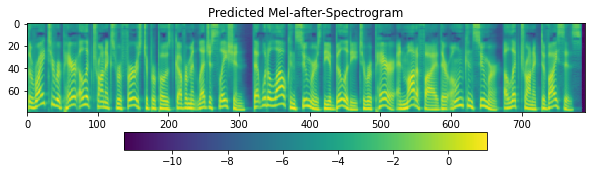

(151, 790)


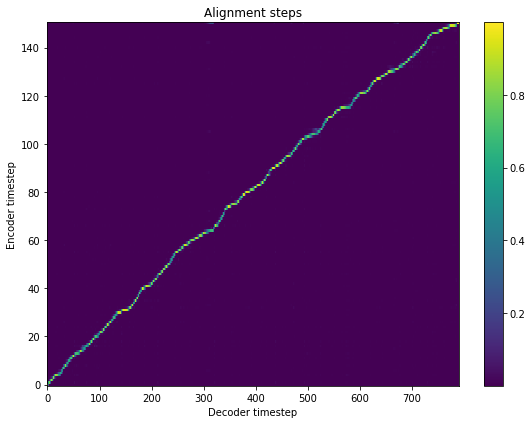

Raw Text Sequence: {DH AH0} {S AY1 N} {S EH1 Z} {DH AE1 T} {DH AH0} {SH AA1 P} {W AA1 Z} {F AO1 R M ER0 L IY0} {CH AH1 K S}, {IH0 M P L AY1 IH0 NG} {DH AE1 T} {DH AH0} {T UW1} {W ER1 D Z} {B IH0 G IH1 N IH0 NG} {W IH1 DH}
Sequence: @ D H @ A H 0   @ S @ A Y 1 @ N   @ S @ E H 1 @ Z   @ D H @ A E 1 @ T   @ D H @ A H 0   @ S H @ A A 1 @ P   @ W @ A A 1 @ Z   @ F @ A O 1 @ R @ M @ E R 0 @ L @ I Y 0   @ C H @ A H 1 @ K @ S ,   @ I H 0 @ M @ P @ L @ A Y 1 @ I H 0 @ N G   @ D H @ A E 1 @ T   @ D H @ A H 0   @ T @ U W 1   @ W @ E R 1 @ D @ Z   @ B @ I H 0 @ G @ I H 1 @ N @ I H 0 @ N G   @ W @ I H 1 @ D H ~
Sequence Input: 208 190 19 248 203 236 19 248 211 263 19 208 187 250 19 208 190 19 249 183 246 19 261 183 263 19 221 195 247 235 214 234 229 19 206 191 233 248 6 19 225 235 246 234 203 225 237 19 208 187 250 19 208 190 19 250 258 19 261 215 207 263 19 205 225 222 226 236 225 237 19 261 226 208 2
torch.Size([1, 374, 80])
torch.Size([1, 374, 75])


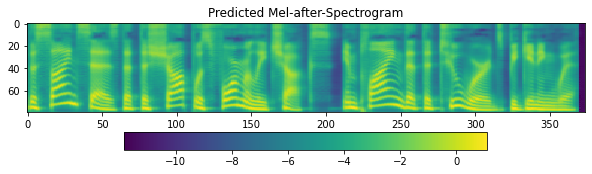

(75, 374)


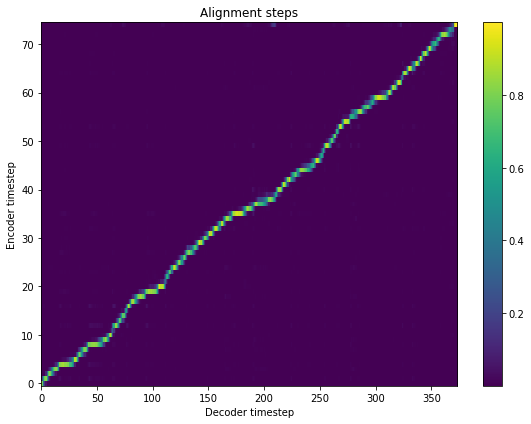

Raw Text Sequence: {Y UW1} {K AE1 N AA0 T} {CH EY1 N JH} {DH AH0} {S T AE1 N D ER0 D} {W EH1 N} {DH AH0} {K ER1 AH0 N T} {S T AE1 N D ER0 D} {EH0 N SH UH1 R Z} {K AH1 S T AH0 M ER0 Z} {W OW1 N T} {Y UW1 S} {EH1 N IY0 TH IH2 NG} {EH1 L S}
Sequence: @ Y @ U W 1   @ K @ A E 1 @ N @ A A 0 @ T   @ C H @ E Y 1 @ N @ J H   @ D H @ A H 0   @ S @ T @ A E 1 @ N @ D @ E R 0 @ D   @ W @ E H 1 @ N   @ D H @ A H 0   @ K @ E R 1 @ A H 0 @ N @ T   @ S @ T @ A E 1 @ N @ D @ E R 0 @ D   @ E H 0 @ N @ S H @ U H 1 @ R @ Z   @ K @ A H 1 @ S @ T @ A H 0 @ M @ E R 0 @ Z   @ W @ O W 1 @ N @ T   @ Y @ U W 1 @ S   @ E H 1 @ N @ I Y 0 @ T H @ I H 2 @ N G   @ E H 1 @ L @ S ~
Sequence Input: 262 258 19 233 187 236 182 250 19 206 219 236 232 19 208 190 19 248 250 187 236 207 214 207 19 261 211 236 19 208 190 19 233 215 190 236 250 19 248 250 187 236 207 214 207 19 210 236 249 254 247 263 19 233 191 248 250 190 235 214 263 19 261 240 236 250 19 262 258 248 19 211 236 229 251 227 237 19 211 234 248 2
torch.Size([1, 4

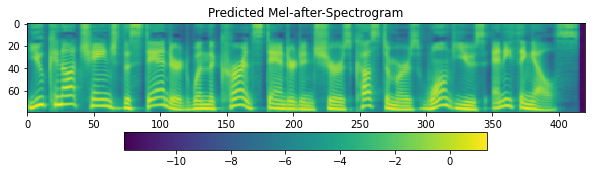

(82, 420)


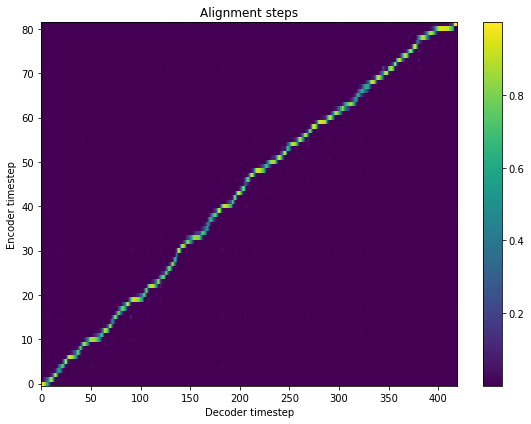

Raw Text Sequence: {HH AW1} {D IH1 D} {DH AH0} {S IH1 M P S AH0 N Z} {G EH1 T} {AH0 W EY1} {W IH1 DH} {DH IH1 S} {W AH1 N}
Sequence: @ H H @ A W 1   @ D @ I H 1 @ D   @ D H @ A H 0   @ S @ I H 1 @ M @ P @ S @ A H 0 @ N @ Z   @ G @ E H 1 @ T   @ A H 0 @ W @ E Y 1   @ W @ I H 1 @ D H   @ D H @ I H 1 @ S   @ W @ A H 1 @ N ~
Sequence Input: 223 199 19 207 226 207 19 208 190 19 248 226 235 246 248 190 236 263 19 222 211 250 19 190 261 219 19 261 226 208 19 208 226 248 19 261 191 236 2
torch.Size([1, 181, 80])
torch.Size([1, 181, 39])


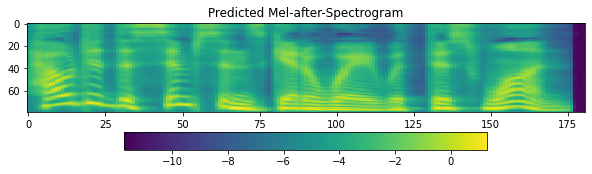

(39, 181)


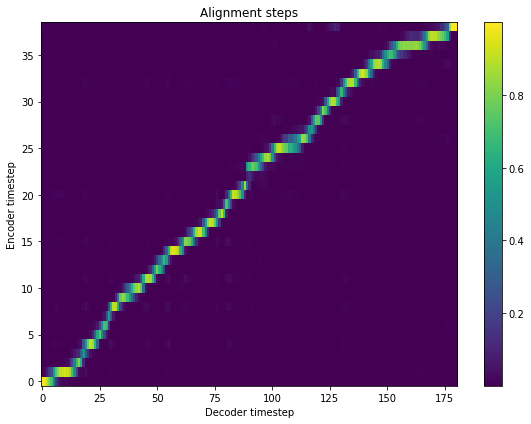

Raw Text Sequence: {AH0 N D} {DH EH1 N} {W AH1 T} {DH EY1} {S EH1 D} {W AA1 Z} {AH0} {V EH1 R IY0} {S P AY1 S IY0} {TH IH1 NG}
Sequence: @ A H 0 @ N @ D   @ D H @ E H 1 @ N   @ W @ A H 1 @ T   @ D H @ E Y 1   @ S @ E H 1 @ D   @ W @ A A 1 @ Z   @ A H 0   @ V @ E H 1 @ R @ I Y 0   @ S @ P @ A Y 1 @ S @ I Y 0   @ T H @ I H 1 @ N G ~
Sequence Input: 190 236 207 19 208 211 236 19 261 191 250 19 208 219 19 248 211 207 19 261 183 263 19 190 19 260 211 247 229 19 248 246 203 248 229 19 251 226 237 2
torch.Size([1, 185, 80])
torch.Size([1, 185, 40])


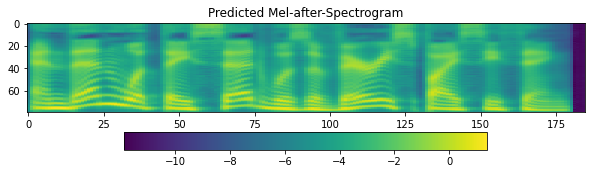

(40, 185)


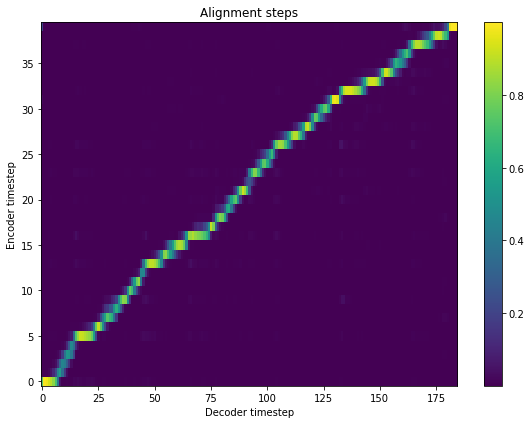

Raw Text Sequence: {P R EH1 Z AH0 D EH2 N T} {T R AH1 M P} {M EH1 T} {W IH1 DH} {AH1 DH ER0} {L IY1 D ER0 Z} {AE1 T} {DH AH0} {G R UW1 P} {AH1 V} {T W EH1 N T IY0} {K AA1 N F ER0 AH0 N S}
Sequence: @ P @ R @ E H 1 @ Z @ A H 0 @ D @ E H 2 @ N @ T   @ T @ R @ A H 1 @ M @ P   @ M @ E H 1 @ T   @ W @ I H 1 @ D H   @ A H 1 @ D H @ E R 0   @ L @ I Y 1 @ D @ E R 0 @ Z   @ A E 1 @ T   @ D H @ A H 0   @ G @ R @ U W 1 @ P   @ A H 1 @ V   @ T @ W @ E H 1 @ N @ T @ I Y 0   @ K @ A A 1 @ N @ F @ E R 0 @ A H 0 @ N @ S ~
Sequence Input: 246 247 211 263 190 207 212 236 250 19 250 247 191 235 246 19 235 211 250 19 261 226 208 19 191 208 214 19 234 230 207 214 263 19 187 250 19 208 190 19 222 247 258 246 19 191 260 19 250 261 211 236 250 229 19 233 183 236 221 214 190 236 248 2
torch.Size([1, 284, 80])
torch.Size([1, 284, 64])


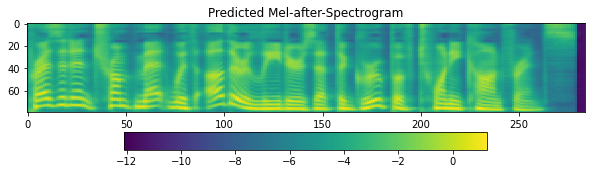

(64, 284)


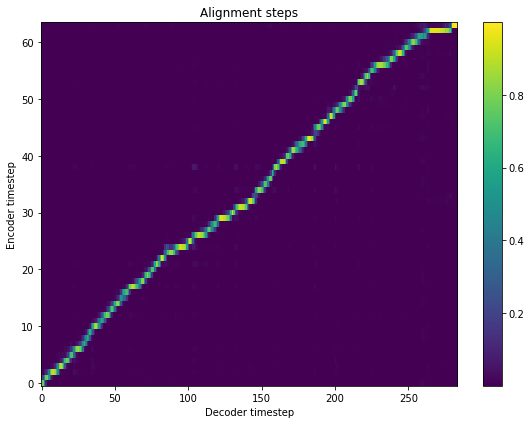

Raw Text Sequence: {AH0 N L EH1 S} {Y UW1} {W ER1 K} {AA1 N} {AH0} {SH IH1 P}, {IH1 T S} {AH0 N L AY1 K L IY0} {DH AE1 T} {Y UW1} {Y UW1 Z} {DH AH0} {W ER1 D} {B OW1 T S W EY0 N} {IH0 N} {EH1 V R IY0 D EY1} {K AA2 N V ER0 S EY1 SH AH0 N}, {S OW1} {IH1 T S} {AH2 N D ER0 S T AE1 N D AH0 B L IY0} {AH0} {T R IH1 K IY0} {W AH1 N}.
Sequence: @ A H 0 @ N @ L @ E H 1 @ S   @ Y @ U W 1   @ W @ E R 1 @ K   @ A A 1 @ N   @ A H 0   @ S H @ I H 1 @ P ,   @ I H 1 @ T @ S   @ A H 0 @ N @ L @ A Y 1 @ K @ L @ I Y 0   @ D H @ A E 1 @ T   @ Y @ U W 1   @ Y @ U W 1 @ Z   @ D H @ A H 0   @ W @ E R 1 @ D   @ B @ O W 1 @ T @ S @ W @ E Y 0 @ N   @ I H 0 @ N   @ E H 1 @ V @ R @ I Y 0 @ D @ E Y 1   @ K @ A A 2 @ N @ V @ E R 0 @ S @ E Y 1 @ S H @ A H 0 @ N ,   @ S @ O W 1   @ I H 1 @ T @ S   @ A H 2 @ N @ D @ E R 0 @ S @ T @ A E 1 @ N @ D @ A H 0 @ B @ L @ I Y 0   @ A H 0   @ T @ R @ I H 1 @ K @ I Y 0   @ W @ A H 1 @ N . ~
Sequence Input: 190 236 234 211 248 19 262 258 19 261 215 233 19 183 236 19 190 19 249 226

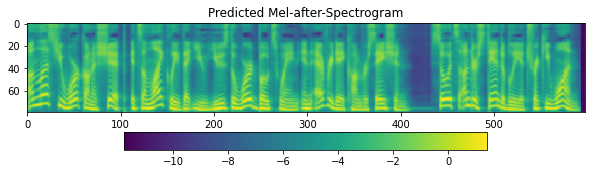

(117, 598)


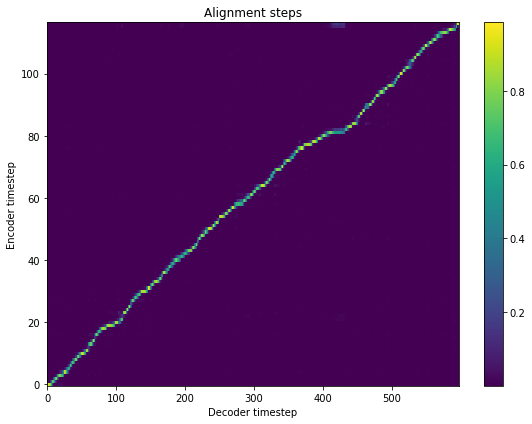

Raw Text Sequence: {P IY1 T ER0} {P AY1 P ER0} {P IH1 K T} {AH0} {P EH1 K} {AH1 V} {P IH1 K AH0 L D} {P EH1 P ER0 Z}. {HH AW1} {M EH1 N IY0} {P IH1 K AH0 L D} {P EH1 P ER0 Z} {D IH1 D} {P IY1 T ER0} {P AY1 P ER0} {P IH1 K}?
Sequence: @ P @ I Y 1 @ T @ E R 0   @ P @ A Y 1 @ P @ E R 0   @ P @ I H 1 @ K @ T   @ A H 0   @ P @ E H 1 @ K   @ A H 1 @ V   @ P @ I H 1 @ K @ A H 0 @ L @ D   @ P @ E H 1 @ P @ E R 0 @ Z .   @ H H @ A W 1   @ M @ E H 1 @ N @ I Y 0   @ P @ I H 1 @ K @ A H 0 @ L @ D   @ P @ E H 1 @ P @ E R 0 @ Z   @ D @ I H 1 @ D   @ P @ I Y 1 @ T @ E R 0   @ P @ A Y 1 @ P @ E R 0   @ P @ I H 1 @ K ? ~
Sequence Input: 246 230 250 214 19 246 203 246 214 19 246 226 233 250 19 190 19 246 211 233 19 191 260 19 246 226 233 190 234 207 19 246 211 246 214 263 7 19 223 199 19 235 211 236 229 19 246 226 233 190 234 207 19 246 211 246 214 263 19 207 226 207 19 246 230 250 214 19 246 203 246 214 19 246 226 233 9 2
torch.Size([1, 370, 80])
torch.Size([1, 370, 78])


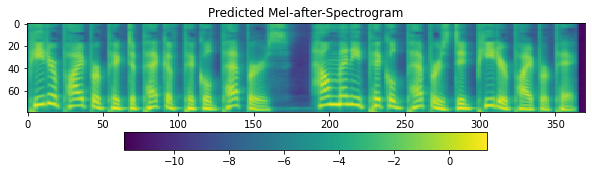

(78, 370)


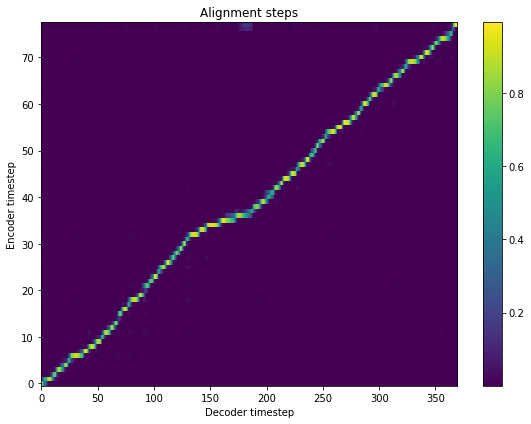

Raw Text Sequence: {DH EH1 R Z} {AH0} {W EY1} {T UW1} {M EH1 ZH ER0} {DH AH0} {AH0 K Y UW1 T} {IH0 M OW1 SH AH0 N AH0 L} {IH0 N T EH1 L AH0 JH AH0 N S} {DH AE1 T} {HH AE1 Z} {N EH1 V ER0} {G AO1 N} {AW1 T} {AH1 V} {S T AY1 L}.
Sequence: @ D H @ E H 1 @ R @ Z   @ A H 0   @ W @ E Y 1   @ T @ U W 1   @ M @ E H 1 @ Z H @ E R 0   @ D H @ A H 0   @ A H 0 @ K @ Y @ U W 1 @ T   @ I H 0 @ M @ O W 1 @ S H @ A H 0 @ N @ A H 0 @ L   @ I H 0 @ N @ T @ E H 1 @ L @ A H 0 @ J H @ A H 0 @ N @ S   @ D H @ A E 1 @ T   @ H H @ A E 1 @ Z   @ N @ E H 1 @ V @ E R 0   @ G @ A O 1 @ N   @ A W 1 @ T   @ A H 1 @ V   @ S @ T @ A Y 1 @ L . ~
Sequence Input: 208 211 247 263 19 190 19 261 219 19 250 258 19 235 211 264 214 19 208 190 19 190 233 262 258 250 19 225 235 240 249 190 236 190 234 19 225 236 250 211 234 190 232 190 236 248 19 208 187 250 19 223 187 263 19 236 211 260 214 19 222 195 236 19 199 250 19 191 260 19 248 250 203 234 7 2
torch.Size([1, 363, 80])
torch.Size([1, 363, 76])


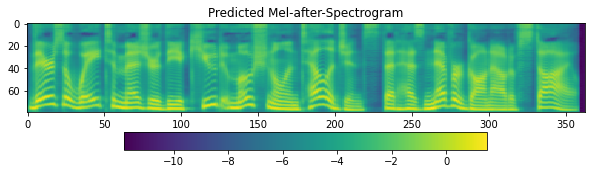

(76, 363)


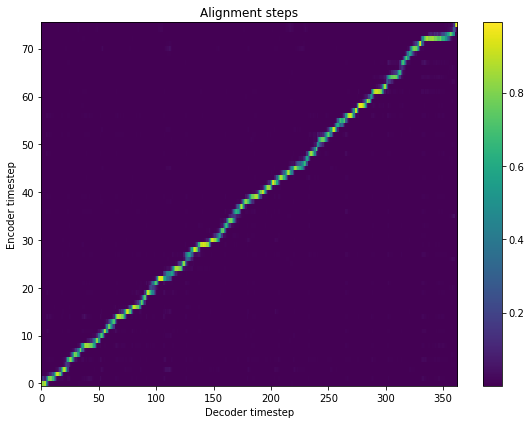

Raw Text Sequence: {DH AH0} {K AH0 M IH1 SH AH0 N} {F ER1 DH ER0} {R EH2 K AH0 M EH1 N D Z} {DH AE1 T} {DH AH0} {S IY1 K R AH0 T} {S ER1 V AH0 S} {K OW0 AO1 R D AH0 N EY2 T} {IH1 T S} {P L AE1 N IH0 NG} {AE1 Z} {K L OW1 S L IY0} {AE1 Z} {P AA1 S AH0 B AH0 L}
Sequence: @ D H @ A H 0   @ K @ A H 0 @ M @ I H 1 @ S H @ A H 0 @ N   @ F @ E R 1 @ D H @ E R 0   @ R @ E H 2 @ K @ A H 0 @ M @ E H 1 @ N @ D @ Z   @ D H @ A E 1 @ T   @ D H @ A H 0   @ S @ I Y 1 @ K @ R @ A H 0 @ T   @ S @ E R 1 @ V @ A H 0 @ S   @ K @ O W 0 @ A O 1 @ R @ D @ A H 0 @ N @ E Y 2 @ T   @ I H 1 @ T @ S   @ P @ L @ A E 1 @ N @ I H 0 @ N G   @ A E 1 @ Z   @ K @ L @ O W 1 @ S @ L @ I Y 0   @ A E 1 @ Z   @ P @ A A 1 @ S @ A H 0 @ B @ A H 0 @ L ~
Sequence Input: 208 190 19 233 190 235 226 249 190 236 19 221 215 208 214 19 247 212 233 190 235 211 236 207 263 19 208 187 250 19 208 190 19 248 230 233 247 190 250 19 248 215 260 190 248 19 233 239 195 247 207 190 236 220 250 19 226 250 248 19 246 234 187 236 225 237 19 187 263 

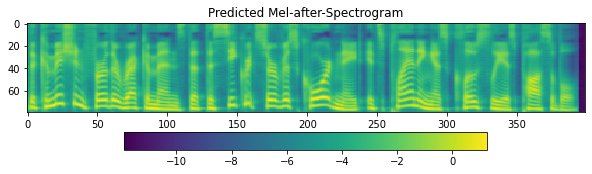

(88, 399)


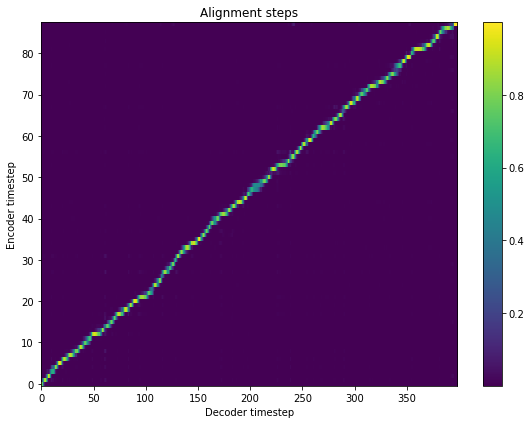

Raw Text Sequence: {W IH1 DH} {AO1 L} {AH1 V} {DH AH0} {F EH1 D ER0 AH0 L} {EY1 JH AH0 N S IY0 Z} {F R AH1 M} {W IH1 CH} {IH1 T} {R AH0 S IY1 V Z} {IH2 N F ER0 M EY1 SH AH0 N}
Sequence: @ W @ I H 1 @ D H   @ A O 1 @ L   @ A H 1 @ V   @ D H @ A H 0   @ F @ E H 1 @ D @ E R 0 @ A H 0 @ L   @ E Y 1 @ J H @ A H 0 @ N @ S @ I Y 0 @ Z   @ F @ R @ A H 1 @ M   @ W @ I H 1 @ C H   @ I H 1 @ T   @ R @ A H 0 @ S @ I Y 1 @ V @ Z   @ I H 2 @ N @ F @ E R 0 @ M @ E Y 1 @ S H @ A H 0 @ N ~
Sequence Input: 261 226 208 19 195 234 19 191 260 19 208 190 19 221 211 207 214 190 234 19 219 232 190 236 248 229 263 19 221 247 191 235 19 261 226 206 19 226 250 19 247 190 248 230 260 263 19 227 236 221 214 235 219 249 190 236 2
torch.Size([1, 273, 80])
torch.Size([1, 273, 57])


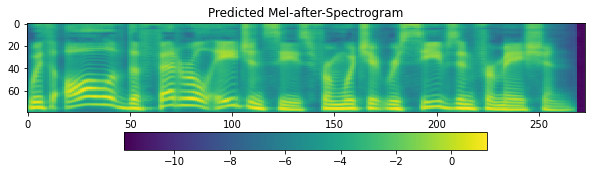

(57, 273)


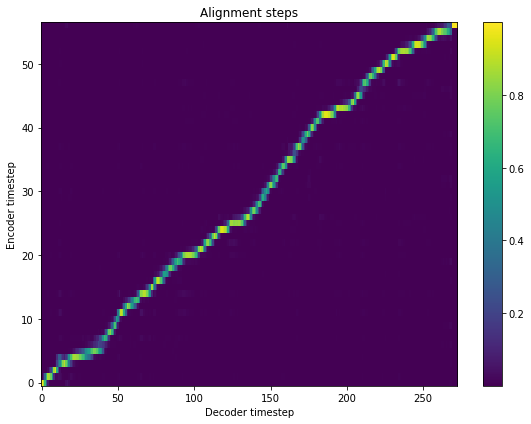

Raw Text Sequence: {P R EH1 Z AH0 D EH2 N T} {T R AH1 M P} {M EH1 T} {W IH1 DH} {AH1 DH ER0} {L IY1 D ER0 Z} {AE1 T} {DH AH0} {G R UW1 P} {AH1 V} {T W EH1 N T IY0} {K AA1 N F ER0 AH0 N S}.
Sequence: @ P @ R @ E H 1 @ Z @ A H 0 @ D @ E H 2 @ N @ T   @ T @ R @ A H 1 @ M @ P   @ M @ E H 1 @ T   @ W @ I H 1 @ D H   @ A H 1 @ D H @ E R 0   @ L @ I Y 1 @ D @ E R 0 @ Z   @ A E 1 @ T   @ D H @ A H 0   @ G @ R @ U W 1 @ P   @ A H 1 @ V   @ T @ W @ E H 1 @ N @ T @ I Y 0   @ K @ A A 1 @ N @ F @ E R 0 @ A H 0 @ N @ S . ~
Sequence Input: 246 247 211 263 190 207 212 236 250 19 250 247 191 235 246 19 235 211 250 19 261 226 208 19 191 208 214 19 234 230 207 214 263 19 187 250 19 208 190 19 222 247 258 246 19 191 260 19 250 261 211 236 250 229 19 233 183 236 221 214 190 236 248 7 2
torch.Size([1, 289, 80])
torch.Size([1, 289, 65])


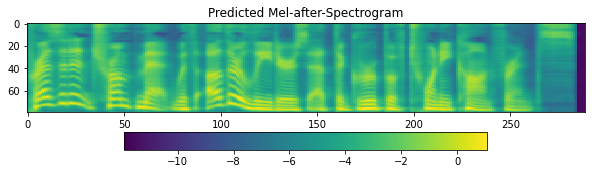

(65, 289)


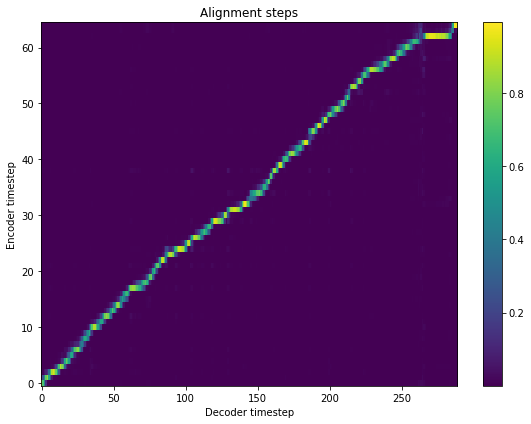

Raw Text Sequence: {N OW1} {T R UW1} {S K AA1 T S M AH0 N}, {AO1 R} {AH0 P IY1 L} {T UW1} {P Y UH1 R AH0 T IY0}, {IH1 Z} {AE1 N} {IH0 N F AO1 R M AH0 L} {F AE1 L AH0 S IY0} {IH0 N} {W IH1 CH} {W AH1 N} {AH0 T EH1 M P T S} {T UW1} {P R AH0 T EH1 K T} {AH0} {Y UW2 N AH0 V ER1 S AH0 L} {JH EH2 N ER0 AH0 L IH0 Z EY1 SH AH0 N} {F R AH1 M} {K AW1 N T ER0} {IH0 G Z AE1 M P AH0 L Z}
Sequence: @ N @ O W 1   @ T @ R @ U W 1   @ S @ K @ A A 1 @ T @ S @ M @ A H 0 @ N ,   @ A O 1 @ R   @ A H 0 @ P @ I Y 1 @ L   @ T @ U W 1   @ P @ Y @ U H 1 @ R @ A H 0 @ T @ I Y 0 ,   @ I H 1 @ Z   @ A E 1 @ N   @ I H 0 @ N @ F @ A O 1 @ R @ M @ A H 0 @ L   @ F @ A E 1 @ L @ A H 0 @ S @ I Y 0   @ I H 0 @ N   @ W @ I H 1 @ C H   @ W @ A H 1 @ N   @ A H 0 @ T @ E H 1 @ M @ P @ T @ S   @ T @ U W 1   @ P @ R @ A H 0 @ T @ E H 1 @ K @ T   @ A H 0   @ Y @ U W 2 @ N @ A H 0 @ V @ E R 1 @ S @ A H 0 @ L   @ J H @ E H 2 @ N @ E R 0 @ A H 0 @ L @ I H 0 @ Z @ E Y 1 @ S H @ A H 0 @ N   @ F @ R @ A H 1 @ M   @ K @ A W 1 @ N @ T 

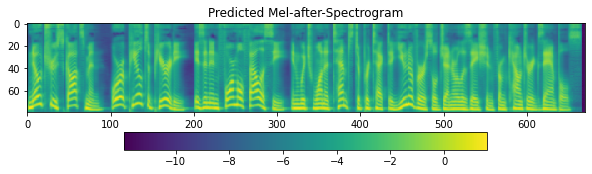

(135, 670)


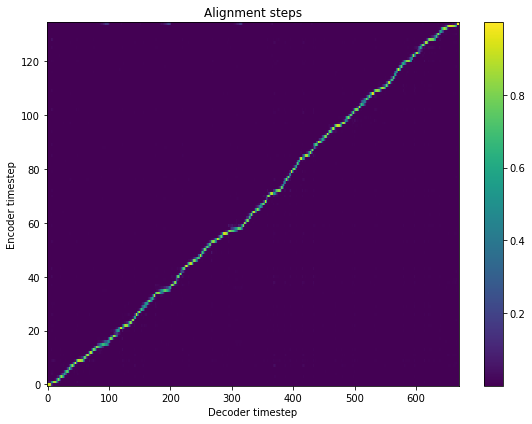

Raw Text Sequence: {DH AH0} {F Y UW1 CH ER0} {IH1 Z} {B Y UW1 T AH0 F AH0 L}
Sequence: @ D H @ A H 0   @ F @ Y @ U W 1 @ C H @ E R 0   @ I H 1 @ Z   @ B @ Y @ U W 1 @ T @ A H 0 @ F @ A H 0 @ L ~
Sequence Input: 208 190 19 221 262 258 206 214 19 226 263 19 205 262 258 250 190 221 190 234 2
torch.Size([1, 101, 80])
torch.Size([1, 101, 21])


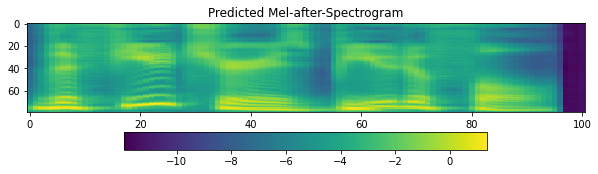

(21, 101)


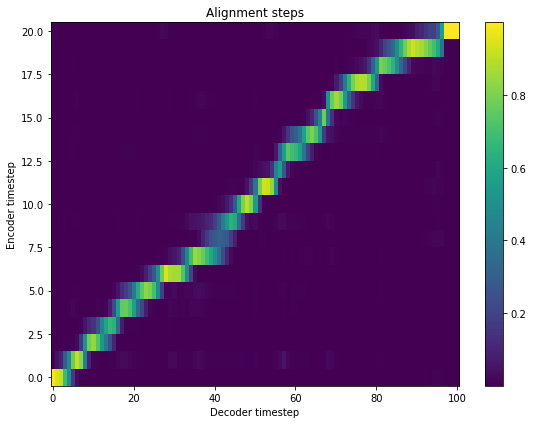

Raw Text Sequence: {DH EH1 R} {IH1 Z} {N OW1} {AE1 T AH0 T UW2 D} {DH AE1 T} {K UH1 D} {N AA1 T} {F AY1 N D} {IH1 T S} {AH1 L T AH0 M AH0 T} {JH AH2 S T AH0 F AH0 K EY1 SH AH0 N} {IH0 N} {DH AH0} {B EH1 N AH0 F IH0 T S} {IH1 T} {G IH1 V Z} {T UW1} {DH AH0} {HH OW1 L}.
Sequence: @ D H @ E H 1 @ R   @ I H 1 @ Z   @ N @ O W 1   @ A E 1 @ T @ A H 0 @ T @ U W 2 @ D   @ D H @ A E 1 @ T   @ K @ U H 1 @ D   @ N @ A A 1 @ T   @ F @ A Y 1 @ N @ D   @ I H 1 @ T @ S   @ A H 1 @ L @ T @ A H 0 @ M @ A H 0 @ T   @ J H @ A H 2 @ S @ T @ A H 0 @ F @ A H 0 @ K @ E Y 1 @ S H @ A H 0 @ N   @ I H 0 @ N   @ D H @ A H 0   @ B @ E H 1 @ N @ A H 0 @ F @ I H 0 @ T @ S   @ I H 1 @ T   @ G @ I H 1 @ V @ Z   @ T @ U W 1   @ D H @ A H 0   @ H H @ O W 1 @ L . ~
Sequence Input: 208 211 247 19 226 263 19 236 240 19 187 250 190 250 259 207 19 208 187 250 19 233 254 207 19 236 183 250 19 221 203 236 207 19 226 250 248 19 191 234 250 190 235 190 250 19 232 192 248 250 190 221 190 233 219 249 190 236 19 225 236 19 208 190

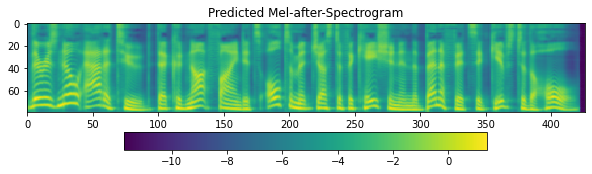

(93, 426)


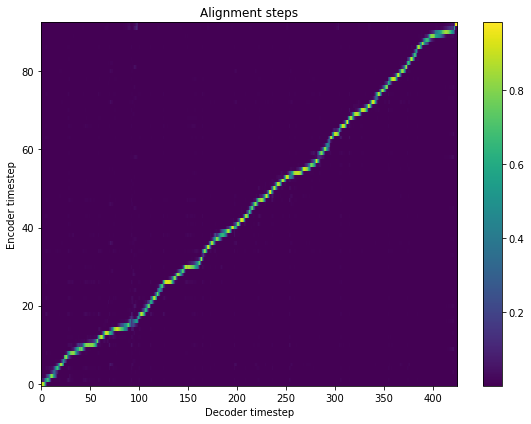

Raw Text Sequence: {HH IY1} {M EY1 K S} {DH AH0} {B EH1 S T} {V OW1 K AH0 L} {D IY1 P} {F EY1 K S} {DH EH1 R} {AA1 R} {IH0 N} {DH AH0} {M AA1 R K AH0 T} {W IH1 DH} {DH AH0} {B EH1 S T} {AA1 D IY0 OW2} {K W AA1 L AH0 T IY0}
Sequence: @ H H @ I Y 1   @ M @ E Y 1 @ K @ S   @ D H @ A H 0   @ B @ E H 1 @ S @ T   @ V @ O W 1 @ K @ A H 0 @ L   @ D @ I Y 1 @ P   @ F @ E Y 1 @ K @ S   @ D H @ E H 1 @ R   @ A A 1 @ R   @ I H 0 @ N   @ D H @ A H 0   @ M @ A A 1 @ R @ K @ A H 0 @ T   @ W @ I H 1 @ D H   @ D H @ A H 0   @ B @ E H 1 @ S @ T   @ A A 1 @ D @ I Y 0 @ O W 2   @ K @ W @ A A 1 @ L @ A H 0 @ T @ I Y 0 ~
Sequence Input: 223 230 19 235 219 233 248 19 208 190 19 205 211 248 250 19 260 240 233 190 234 19 207 230 246 19 221 219 233 248 19 208 211 247 19 183 247 19 225 236 19 208 190 19 235 183 247 233 190 250 19 261 226 208 19 208 190 19 205 211 248 250 19 183 207 229 241 19 233 261 183 234 190 250 229 2
torch.Size([1, 329, 80])
torch.Size([1, 329, 76])


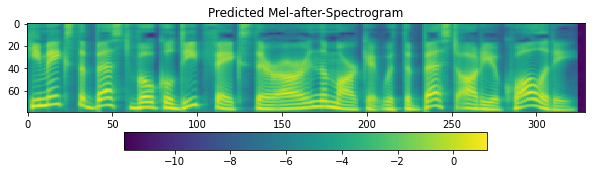

(76, 329)


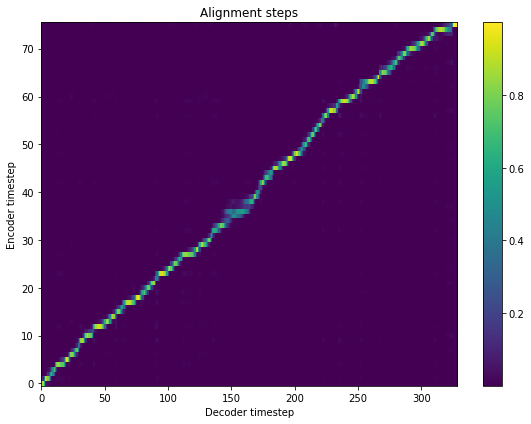

In [ ]:
from IPython.display import Audio as IPAUD
import IPython.display as ipd
model.decoder.max_decoder_steps = 10000
sentence = """
The right to repair electronics refers to proposed government legislation that would allow consumers the ability to repair and modify their own consumer electronic devices
the sign says that the shop was "Formerly Chuck's", implying that the two words beginning with
you cannot change the standard when the current standard ensures customers wont use anything else
how did the simpsons get away with this one
and then what they said was a very spicy thing
President Trump met with other leaders at the Group of twenty conference
Unless you work on a ship, it's unlikely that you use the word boatswain in everyday conversation, so it's understandably a tricky one.
Peter Piper picked a peck of pickled peppers. How many pickled peppers did Peter Piper pick?
There’s a way to measure the acute emotional intelligence that has never gone out of style.
The Commission further recommends that the Secret Service coordinate its planning as closely as possible 
with all of the Federal agencies from which it receives information
President Trump met with other leaders at the Group of twenty conference.
No true Scotsman, or appeal to purity, is an informal fallacy in which one attempts to protect a universal generalization from counter examples
The future is beautiful
There is no attitude that could not find its ultimate justification in the benefits it gives to the whole.
He makes the best vocal deep fakes there are in the market with the best audio quality
"""
sarate = 22050
intxt = sentence
for li in intxt.split("\n"):
  if len(li) < 1:
    continue

  aud = do_inference(i_arpa(li))
  ipd.display(IPAUD(aud,rate=sarate))